<a href="https://colab.research.google.com/github/kormladorwu/MyPortfolio/blob/main/transfer_learning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Mount Google Drive to access files in Google Colab



from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

# Load the dataset from Google Drive

import pandas as pd

file_path = '/content/drive/MyDrive/IDDataset.csv'
df = pd.read_csv(file_path)


In [ ]:
#STEP 2: Data Cleaning

# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Remove non-useful columns
cols_to_drop = ['Flow_ID', 'Src_IP', 'Dst_IP']  # adjust if present
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(df.shape)


(461696, 83)


In [ ]:
# STEP 2: Data Cleaning continuation

import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)  # or df.fillna(df.mean(), inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].clip(upper=1e6)
print(df.shape)


(461373, 83)


In [ ]:
#STEP 3: Feature Encoding (Categorical → Numeric)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = encoder.fit_transform(df[col])


In [ ]:
# -----------------------------
# STEP 3:continuation

# Features: all columns except the target 'Label'
X = df.drop('Label', axis=1)

# Target: the 'Label' column
y = df['Label']

# Convert features to float32 to save memory
X = X.astype('float32')

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (461373, 82)
Labels shape: (461373,)


In [ ]:
#STEP 4: Normalization

from sklearn.preprocessing import StandardScaler

X = df.drop('Label', axis=1)
y = df['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#STEP 5: Temporal Sequencing (Sliding Window)

import numpy as np

def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y.values, window_size=10)

print(X_seq.shape)


(461363, 10, 82)


In [ ]:

# STEP 6: Train-Test Split (Memory Optimized)

from sklearn.model_selection import train_test_split

# Optional: downsample to 100k rows because original set is too large
sample_size = 100_000
if len(X) > sample_size:
    X_small = X.sample(n=sample_size, random_state=42)
    y_small = y.loc[X_small.index]
else:
    X_small = X
    y_small = y

# Split into training and test sets into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (80000, 82)
Test set shape: (20000, 82)


In [ ]:
# STEP 7: Apply SMOTE to Training Set

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape, y_train.shape)
print("Resampled training set shape:", X_train_res.shape, y_train_res.shape)

Original training set shape: (80000, 82) (80000,)
Resampled training set shape: (146794, 82) (146794,)


In [ ]:
# STEP 8: Feature Selection

from sklearn.feature_selection import SelectKBest, mutual_info_classif
import numpy as np

# Convert training DataFrame to NumPy array
X_train_np = X_train_res.to_numpy()

# Flatten for feature selection (samples × features)
X_train_flat = X_train_np.reshape(X_train_np.shape[0], -1)

# Select top 50 features using mutual information
selector = SelectKBest(score_func=mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train_flat, y_train_res)

# Reshape back to 3D for LSTM model
X_train_selected = X_train_selected.reshape(X_train_selected.shape[0], 1, -1)

# Apply the same feature selection to the test set
X_test_np = X_test.to_numpy()
X_test_flat = X_test_np.reshape(X_test_np.shape[0], -1)
X_test_selected = selector.transform(X_test_flat)

# Reshape back to 3D for LSTM model
X_test_selected = X_test_selected.reshape(X_test_selected.shape[0], 1, -1)

print("Shape after feature selection (training):", X_train_selected.shape)
print("Shape after feature selection (test):", X_test_selected.shape)

Shape after feature selection (training): (146794, 1, 50)
Shape after feature selection (test): (20000, 1, 50)


In [ ]:
#Create a Validation Set

from sklearn.model_selection import train_test_split

# Split the training data into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_selected,
    y_train_res,
    test_size=0.2,
    random_state=42,
    stratify=y_train_res
)

print(X_train_final.shape)
print(X_val.shape)

(117435, 1, 50)
(29359, 1, 50)


In [ ]:
#STEP 9: Building Temporal Transformer Encoder (PyTorch)

import torch
import torch.nn as nn

class TemporalTransformer(nn.Module):
    def __init__(self, input_dim, num_heads=5, hidden_dim=64): # Changed num_heads from 4 to 5
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

In [ ]:
#STEP 10: Transfer Learning Strategy

model = TemporalTransformer(input_dim=X_train_selected.shape[2])

# Load pretrained weights (example)
# model.load_state_dict(torch.load("pretrained_model.pth"), strict=False)

/tmp/ipykernel_1335/4029394563.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)


In [ ]:
#STEP 11: Domain Adaptation (Gradient Reversal)

class DomainDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(x.mean(dim=1))


In [ ]:
#STEP 12: Hyperparameter Optimization (Optuna)

!pip install optuna
import optuna

def objective(trial):
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    heads = trial.suggest_int('heads', 2, 8)
    hidden = trial.suggest_int('hidden', 32, 128)
    return 0.85  # placeholder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.1 MB/s eta 0:00:00


In [ ]:
#(Training Loop)
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TemporalTransformer(input_dim=X_train_selected.shape[2]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.long).to(device)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long).to(device)

# Store history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 80

for epoch in range(epochs):

    #####################
    # TRAINING
    #####################
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    _, predicted = torch.max(outputs, 1)

    train_accuracy = accuracy_score(
        y_train_tensor.cpu(),
        predicted.cpu()
    )

    train_accs.append(train_accuracy)

    #####################
    # VALIDATION
    #####################
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val_tensor)

        val_loss = criterion(val_outputs, y_val_tensor)

        val_losses.append(val_loss.item())

        _, val_predicted = torch.max(val_outputs, 1)

        val_accuracy = accuracy_score(
            y_val_tensor.cpu(),
            val_predicted.cpu()
        )

        val_accs.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss:{loss.item():.4f} "
          f"Val Loss:{val_loss.item():.4f} "
          f"Train Acc:{train_accuracy:.4f} "
          f"Val Acc:{val_accuracy:.4f}")

/tmp/ipykernel_1335/4029394563.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)


Epoch 1/80 Train Loss:0.7774 Val Loss:0.6782 Train Acc:0.4897 Val Acc:0.5910
Epoch 2/80 Train Loss:0.6841 Val Loss:0.6040 Train Acc:0.5810 Val Acc:0.6929
Epoch 3/80 Train Loss:0.6135 Val Loss:0.5498 Train Acc:0.6944 Val Acc:0.8062
Epoch 4/80 Train Loss:0.5605 Val Loss:0.5114 Train Acc:0.7831 Val Acc:0.8114
Epoch 5/80 Train Loss:0.5224 Val Loss:0.4841 Train Acc:0.8033 Val Acc:0.8122
Epoch 6/80 Train Loss:0.4951 Val Loss:0.4645 Train Acc:0.8072 Val Acc:0.8101
Epoch 7/80 Train Loss:0.4735 Val Loss:0.4500 Train Acc:0.8091 Val Acc:0.8088
Epoch 8/80 Train Loss:0.4589 Val Loss:0.4383 Train Acc:0.8090 Val Acc:0.8092
Epoch 9/80 Train Loss:0.4468 Val Loss:0.4278 Train Acc:0.8092 Val Acc:0.8103
Epoch 10/80 Train Loss:0.4362 Val Loss:0.4174 Train Acc:0.8103 Val Acc:0.8117
Epoch 11/80 Train Loss:0.4266 Val Loss:0.4069 Train Acc:0.8112 Val Acc:0.8142
Epoch 12/80 Train Loss:0.4171 Val Loss:0.3967 Train Acc:0.8135 Val Acc:0.8166
Epoch 13/80 Train Loss:0.4081 Val Loss:0.3871 Train Acc:0.8154 Val Acc:0.

In [ ]:
if 'TemporalTransformer' in globals():
    print(f"TemporalTransformer is defined and is of type: {type(TemporalTransformer)}")
else:
    print("TemporalTransformer is not defined in the current namespace. Please ensure cell CO1p5SfPHG2b has been executed.")

TemporalTransformer is defined and is of type: <class 'type'>


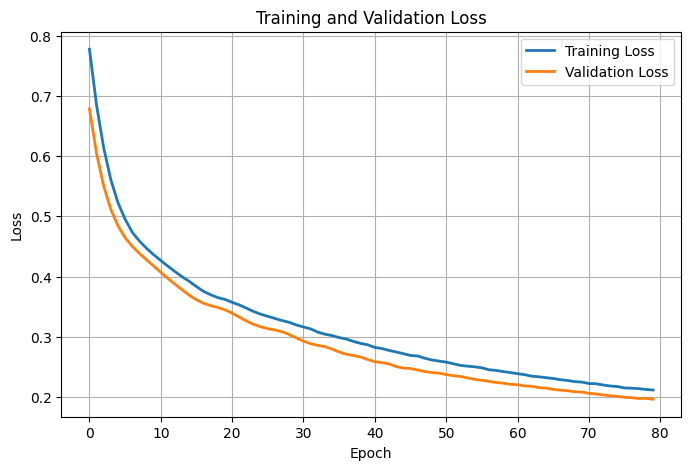

In [ ]:
#Plot Training & Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

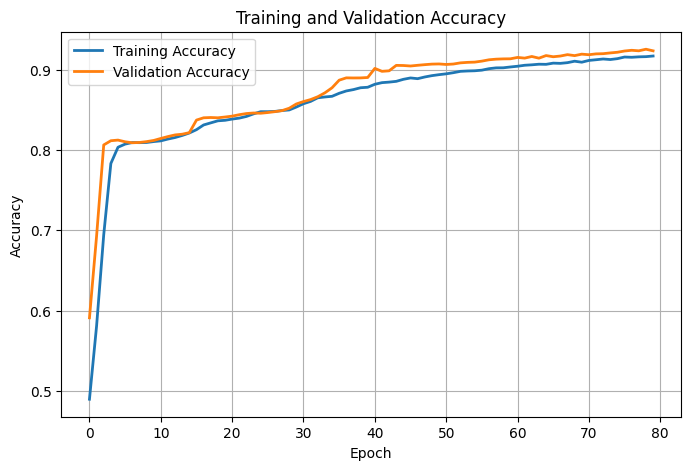

In [ ]:
#Plot Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(train_accs, label='Training Accuracy', linewidth=2)
plt.plot(val_accs, label='Validation Accuracy', linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

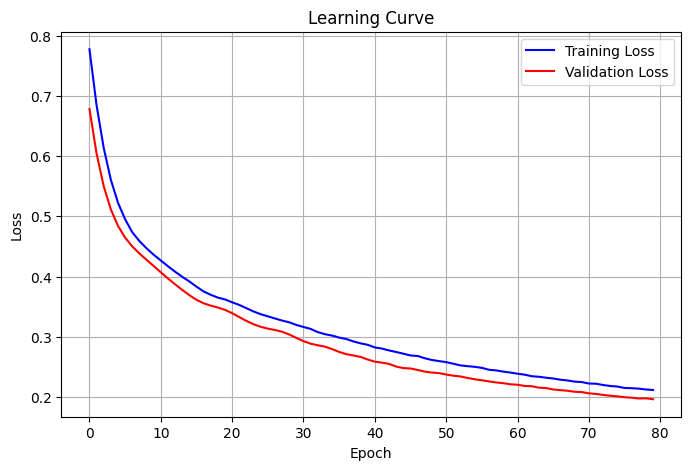

In [ ]:
#learning curve
plt.figure(figsize=(8,5))

plt.plot(train_losses, color='blue', label='Training Loss')

plt.plot(val_losses, color='red', label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# STEP 14: Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score

model.eval()
X_test_tensor = torch.tensor(X_test_selected, dtype=torch.float32).to(device)  # Use X_test_selected

with torch.no_grad():
    preds = model(X_test_tensor)
    y_pred = torch.argmax(preds, dim=1).cpu().numpy()

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)       # <-- Added F1-Score
auc = roc_auc_score(y_test, y_pred)

# Confusion matrix & FPR
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print("Confusion Matrix Percentages (%):")
print(np.round(cm_percent, 2))
FPR = cm[0][1] / (cm[0][0] + cm[0][1])


# Zero-day Detection Rate = recall
zero_day_rate = recall


# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)                # <-- Print F1
print("AUC-ROC:", auc)
print("Zero-day Detection Rate:", zero_day_rate)
print("False Positive Rate:", FPR)

Confusion Matrix Percentages (%):
[[94.38  5.62]
 [ 7.15 92.85]]
Accuracy: 0.94255
Precision: 0.5978939157566303
Recall: 0.9285281647486372
F1-Score: 0.7274021352313167
AUC-ROC: 0.936169908304887
Zero-day Detection Rate: 0.9285281647486372
False Positive Rate: 0.056188348138863156


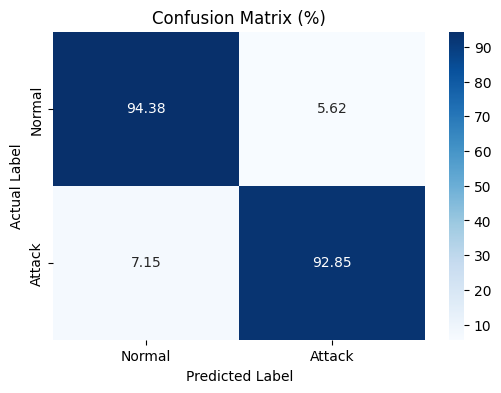

In [ ]:
#graph for confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix percentages
cm_percent = np.array([[94.38, 5.62],
                       [7.15, 92.85]])

# Labels
labels = ["Normal", "Attack"]

plt.figure(figsize=(6,4))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (%)")
plt.show()

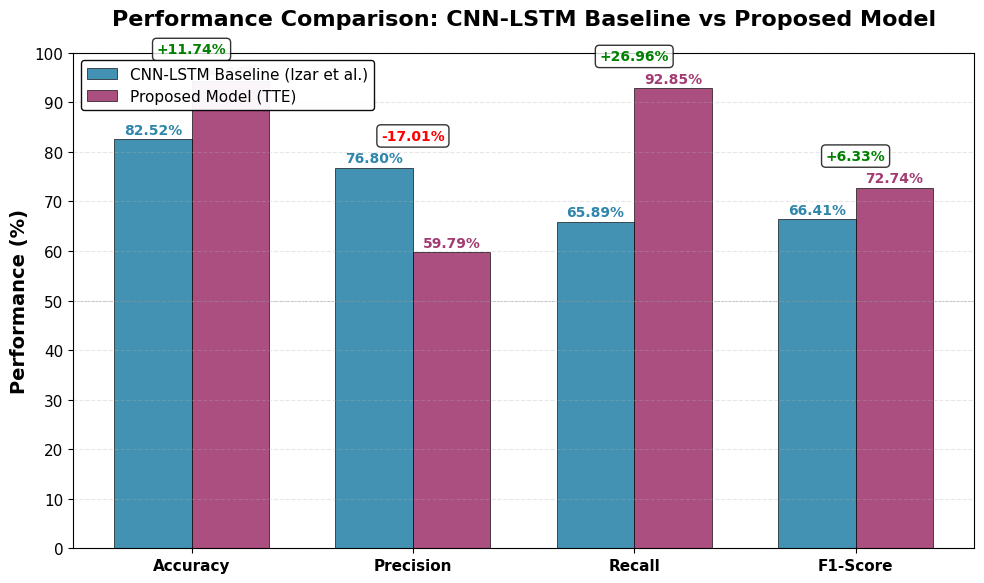

In [ ]:
# Performance metrics evaluation

import matplotlib.pyplot as plt
import numpy as np


plt.style.use('default')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# Data
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline = [82.52, 76.80, 65.89, 66.41]
proposed = [94.26, 59.79, 92.85, 72.74]

# Calculate differences for annotations
differences = [proposed[i] - baseline[i] for i in range(len(metrics))]

# Set up bar positions
x = np.arange(len(metrics))
width = 0.35  # width of bars

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars1 = ax.bar(x - width/2, baseline, width,
               label='CNN-LSTM Baseline (Izar et al.)',
               color='#2E86AB',  # Blue
               edgecolor='black',
               linewidth=0.5,
               alpha=0.9)

bars2 = ax.bar(x + width/2, proposed, width,
               label='Proposed Model (TTE)',
               color='#A23B72',  # Purple
               edgecolor='black',
               linewidth=0.5,
               alpha=0.9)

# Customize the chart
ax.set_ylabel('Performance (%)', fontweight='bold')
ax.set_title('Performance Comparison: CNN-LSTM Baseline vs Proposed Model',
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#2E86AB')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#A23B72')

# Add difference annotations at the top
for i, diff in enumerate(differences):
    color = 'green' if diff > 0 else 'red'
    symbol = '+' if diff > 0 else ''
    max_height = max(baseline[i], proposed[i])
    ax.text(i, max_height + 5, f'{symbol}{diff:.2f}%',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add legend
ax.legend(loc='upper left', framealpha=0.95, edgecolor='black')

# Add a horizontal line at 50% for reference
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Adjust layout and save
plt.tight_layout()

# Save high-resolution image for thesis
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('performance_comparison.pdf', bbox_inches='tight')  # Vector format for thesis

# Display the plot
plt.show()